# Image Metadata Analysis for Tampering Detection

This notebook analyzes image metadata (EXIF data) to detect when images were tampered or modified.

## Features
- Extract comprehensive EXIF metadata from images
- Analyze timestamps (creation, modification, digitization dates)
- Detect inconsistencies that indicate tampering
- Identify missing or suspicious metadata
- Generate detailed tampering reports


## Imports and Setup


In [3]:
import os
import json
from datetime import datetime
from pathlib import Path
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

%matplotlib inline
sns.set(style='whitegrid', context='notebook', palette='deep')

# Try to import additional metadata libraries
try:
    import exifread
    EXIFREAD_AVAILABLE = True
except ImportError:
    EXIFREAD_AVAILABLE = False
    print("Note: exifread not available. Install with: pip install exifread")

try:
    import piexif
    PIEXIF_AVAILABLE = True
except ImportError:
    PIEXIF_AVAILABLE = False
    print("Note: piexif not available. Install with: pip install piexif")


## Configuration


In [2]:
# Configuration
TEST_IMAGES_DIR = 'datasets/ai_detection/test'  # Directory containing test images
RESULTS_DIR = 'metadata_analysis_results'  # Directory to save analysis results

# Create results directory
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Test images directory: {TEST_IMAGES_DIR}")
print(f"Results directory: {RESULTS_DIR}")


Test images directory: datasets/ai_detection/test
Results directory: metadata_analysis_results


## Metadata Extraction Functions


In [3]:
def get_exif_data(image_path):
    """Extract EXIF data from image using PIL."""
    try:
        with Image.open(image_path) as img:
            exif_data = img._getexif()
            if exif_data is not None:
                exif = {}
                for tag_id, value in exif_data.items():
                    tag = TAGS.get(tag_id, tag_id)
                    exif[tag] = value
                return exif
            else:
                return {}
    except Exception as e:
        print(f"Error reading EXIF from {image_path}: {e}")
        return {}


def get_exifread_data(image_path):
    """Extract detailed EXIF data using exifread library."""
    if not EXIFREAD_AVAILABLE:
        return {}
    
    try:
        with open(image_path, 'rb') as f:
            tags = exifread.process_file(f, details=True)
            exif_data = {}
            for tag in tags.keys():
                if tag not in ['JPEGThumbnail', 'TIFFThumbnail', 'Filename', 'EXIF MakerNote']:
                    exif_data[tag] = str(tags[tag])
            return exif_data
    except Exception as e:
        print(f"Error reading EXIF with exifread from {image_path}: {e}")
        return {}


def parse_datetime(date_string):
    """Parse datetime string from EXIF data."""
    if not date_string:
        return None
    
    # Common EXIF datetime formats
    formats = [
        '%Y:%m:%d %H:%M:%S',
        '%Y-%m-%d %H:%M:%S',
        '%Y:%m:%d',
        '%Y-%m-%d',
    ]
    
    for fmt in formats:
        try:
            return datetime.strptime(str(date_string), fmt)
        except (ValueError, TypeError):
            continue
    
    return None


def get_file_timestamps(image_path):
    """Get file system timestamps."""
    stat = os.stat(image_path)
    return {
        'file_created': datetime.fromtimestamp(stat.st_birthtime if hasattr(stat, 'st_birthtime') else stat.st_ctime),
        'file_modified': datetime.fromtimestamp(stat.st_mtime),
        'file_accessed': datetime.fromtimestamp(stat.st_atime)
    }


In [4]:
def analyze_image_metadata(image_path):
    """
    Comprehensive metadata analysis for a single image.
    Returns a dictionary with all extracted information and tampering indicators.
    """
    result = {
        'image_path': str(image_path),
        'image_name': os.path.basename(image_path),
        'has_exif': False,
        'exif_data': {},
        'timestamps': {},
        'file_timestamps': {},
        'tampering_indicators': [],
        'tampering_score': 0,
        'metadata_completeness': 0,
        'analysis_summary': {}
    }
    
    # Get file timestamps
    try:
        result['file_timestamps'] = get_file_timestamps(image_path)
    except Exception as e:
        result['tampering_indicators'].append(f"Error reading file timestamps: {e}")
    
    # Get EXIF data using PIL
    exif_pil = get_exif_data(image_path)
    result['exif_data'] = exif_pil
    result['has_exif'] = len(exif_pil) > 0
    
    # Get detailed EXIF using exifread if available
    if EXIFREAD_AVAILABLE:
        exif_detailed = get_exifread_data(image_path)
        result['exif_data'].update(exif_detailed)
    
    # Extract key timestamps from EXIF
    timestamp_fields = {
        'DateTime': 'DateTime',
        'DateTimeOriginal': 'DateTimeOriginal',
        'DateTimeDigitized': 'DateTimeDigitized',
        'EXIF DateTimeOriginal': 'EXIF DateTimeOriginal',
        'EXIF DateTimeDigitized': 'EXIF DateTimeDigitized',
        'Image DateTime': 'Image DateTime'
    }
    
    for key, label in timestamp_fields.items():
        if key in result['exif_data']:
            dt = parse_datetime(result['exif_data'][key])
            if dt:
                result['timestamps'][label] = dt
    
    # Calculate metadata completeness
    expected_fields = ['DateTime', 'DateTimeOriginal', 'Make', 'Model', 'Software']
    found_fields = sum(1 for field in expected_fields if field in result['exif_data'])
    result['metadata_completeness'] = (found_fields / len(expected_fields)) * 100
    
    # Tampering Detection Logic
    tampering_score = 0
    indicators = []
    
    # 1. Check if EXIF data is missing (suspicious)
    if not result['has_exif']:
        tampering_score += 20
        indicators.append("No EXIF data found - image may have been stripped of metadata")
    
    # 2. Check for missing critical timestamps
    if 'DateTimeOriginal' not in result['timestamps']:
        tampering_score += 15
        indicators.append("Missing DateTimeOriginal - original capture time unknown")
    
    # 3. Check for timestamp inconsistencies
    timestamps = list(result['timestamps'].values())
    if len(timestamps) > 1:
        # Check if timestamps are in logical order
        sorted_timestamps = sorted(timestamps)
        if timestamps != sorted_timestamps:
            tampering_score += 25
            indicators.append("Timestamp inconsistencies detected - timestamps not in chronological order")
    
    # 4. Compare EXIF timestamps with file timestamps
    if result['timestamps'] and result['file_timestamps']:
        exif_times = list(result['timestamps'].values())
        file_modified = result['file_timestamps'].get('file_modified')
        
        if file_modified and exif_times:
            # If file was modified after EXIF timestamp, might indicate tampering
            latest_exif = max(exif_times)
            if file_modified > latest_exif:
                time_diff = (file_modified - latest_exif).total_seconds() / 3600  # hours
                if time_diff > 1:  # More than 1 hour difference
                    tampering_score += 10
                    indicators.append(f"File modified {time_diff:.1f} hours after EXIF timestamp - possible tampering")
    
    # 5. Check for editing software indicators
    software = result['exif_data'].get('Software', '')
    if software:
        editing_software = ['photoshop', 'gimp', 'lightroom', 'paint', 'editor', 'edit']
        if any(term in str(software).lower() for term in editing_software):
            tampering_score += 15
            indicators.append(f"Editing software detected: {software}")
    
    # 6. Check for suspicious metadata patterns
    if 'Make' in result['exif_data'] and 'Model' in result['exif_data']:
        make = str(result['exif_data']['Make']).lower()
        model = str(result['exif_data']['Model']).lower()
        # Some AI-generated images have generic or missing camera info
        if 'unknown' in make or 'unknown' in model or make == '' or model == '':
            tampering_score += 10
            indicators.append("Missing or generic camera information")
    
    # 7. Check for GPS data (real photos often have GPS, AI-generated usually don't)
    has_gps = any('GPS' in key or 'gps' in key.lower() for key in result['exif_data'].keys())
    if not has_gps and result['has_exif']:
        # Not necessarily tampering, but worth noting
        indicators.append("No GPS data found (may indicate AI-generated or processed image)")
    
    result['tampering_score'] = min(tampering_score, 100)  # Cap at 100
    result['tampering_indicators'] = indicators
    
    # Create summary
    result['analysis_summary'] = {
        'likely_tampered': tampering_score >= 50,
        'tampering_confidence': 'High' if tampering_score >= 70 else 'Medium' if tampering_score >= 40 else 'Low',
        'metadata_quality': 'Complete' if result['metadata_completeness'] >= 80 else 'Partial' if result['metadata_completeness'] >= 40 else 'Minimal',
        'estimated_tampering_time': None
    }
    
    # Estimate tampering time (if file modified after EXIF timestamp)
    if result['timestamps'] and result['file_timestamps']:
        file_modified = result['file_timestamps'].get('file_modified')
        if file_modified:
            exif_times = list(result['timestamps'].values())
            if exif_times:
                latest_exif = max(exif_times)
                if file_modified > latest_exif:
                    result['analysis_summary']['estimated_tampering_time'] = file_modified
    
    return result


## Analyze Single Image


In [5]:
def print_metadata_report(analysis_result):
    """Print a formatted metadata analysis report."""
    print("=" * 80)
    print(f"METADATA ANALYSIS REPORT: {analysis_result['image_name']}")
    print("=" * 80)
    
    print(f"\nImage Path: {analysis_result['image_path']}")
    print(f"Has EXIF Data: {analysis_result['has_exif']}")
    print(f"Metadata Completeness: {analysis_result['metadata_completeness']:.1f}%")
    
    # Timestamps
    print("\n--- TIMESTAMPS ---")
    if analysis_result['timestamps']:
        for label, dt in analysis_result['timestamps'].items():
            print(f"  {label}: {dt.strftime('%Y-%m-%d %H:%M:%S')}")
    else:
        print("  No EXIF timestamps found")
    
    print("\n--- FILE TIMESTAMPS ---")
    for label, dt in analysis_result['file_timestamps'].items():
        print(f"  {label}: {dt.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Key EXIF fields
    print("\n--- KEY EXIF INFORMATION ---")
    key_fields = ['Make', 'Model', 'Software', 'Artist', 'Copyright']
    for field in key_fields:
        if field in analysis_result['exif_data']:
            print(f"  {field}: {analysis_result['exif_data'][field]}")
    
    # Tampering Analysis
    print("\n--- TAMPERING ANALYSIS ---")
    print(f"Tampering Score: {analysis_result['tampering_score']}/100")
    summary = analysis_result['analysis_summary']
    print(f"Likely Tampered: {summary['likely_tampered']}")
    print(f"Confidence: {summary['tampering_confidence']}")
    print(f"Metadata Quality: {summary['metadata_quality']}")
    
    if summary['estimated_tampering_time']:
        print(f"Estimated Tampering Time: {summary['estimated_tampering_time'].strftime('%Y-%m-%d %H:%M:%S')}")
    
    if analysis_result['tampering_indicators']:
        print("\nTampering Indicators:")
        for i, indicator in enumerate(analysis_result['tampering_indicators'], 1):
            print(f"  {i}. {indicator}")
    else:
        print("\nNo significant tampering indicators found.")
    
    print("\n" + "=" * 80)


# Example: Analyze a single image
# Uncomment and provide image path to test
# image_path = 'datasets/ai_detection/test/real_1.jpg'
# result = analyze_image_metadata(image_path)
# print_metadata_report(result)


## Batch Analysis - Analyze Multiple Images


In [6]:
def analyze_directory(directory_path, image_extensions=('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
    """Analyze all images in a directory."""
    results = []
    
    if not os.path.exists(directory_path):
        print(f"Error: Directory {directory_path} does not exist")
        return results
    
    # Get all image files
    image_files = []
    for ext in image_extensions:
        image_files.extend(Path(directory_path).glob(f"*{ext}"))
        image_files.extend(Path(directory_path).glob(f"*{ext.upper()}"))
    
    print(f"Found {len(image_files)} images to analyze...")
    
    for img_path in image_files:
        print(f"Analyzing: {img_path.name}...")
        result = analyze_image_metadata(str(img_path))
        results.append(result)
    
    return results


# Analyze test images directory
if os.path.exists(TEST_IMAGES_DIR):
    print(f"Analyzing images in: {TEST_IMAGES_DIR}")
    analysis_results = analyze_directory(TEST_IMAGES_DIR)
    print(f"\n✓ Analysis complete! Analyzed {len(analysis_results)} images.")
else:
    print(f"Directory {TEST_IMAGES_DIR} not found. Please update TEST_IMAGES_DIR.")
    analysis_results = []


Analyzing images in: datasets/ai_detection/test
Found 24 images to analyze...
Analyzing: Ankita_with_heart_filter.jpg...
Analyzing: fake_9.jpg...
Analyzing: gemini_2.jpg...
Analyzing: fake_8.jpg...
Analyzing: gemini_1.jpg...
Analyzing: real_8.jpg...
Analyzing: real_9.jpg...
Analyzing: real_10.jpg...
Analyzing: real_7.jpg...
Analyzing: real_6.jpg...
Analyzing: fake_1.jpg...
Analyzing: fake_3.jpg...
Analyzing: real_4.jpg...
Analyzing: real_5.jpg...
Analyzing: mata_pandal.jpg...
Analyzing: fake_2.jpg...
Analyzing: fake_6.jpg...
Analyzing: real_1.jpg...
Analyzing: fake_10.jpg...
Analyzing: fake_7.jpg...
Analyzing: fake_5.jpg...
Analyzing: real_2.jpg...
Analyzing: real_3.jpg...
Analyzing: fake_4.jpg...

✓ Analysis complete! Analyzed 24 images.


## Results Summary and Visualization


In [7]:
def create_summary_dataframe(results):
    """Create a pandas DataFrame from analysis results."""
    if not results:
        return pd.DataFrame()
    
    rows = []
    for result in results:
        row = {
            'image_name': result['image_name'],
            'has_exif': result['has_exif'],
            'metadata_completeness': result['metadata_completeness'],
            'tampering_score': result['tampering_score'],
            'likely_tampered': result['analysis_summary']['likely_tampered'],
            'tampering_confidence': result['analysis_summary']['tampering_confidence'],
            'metadata_quality': result['analysis_summary']['metadata_quality'],
            'num_indicators': len(result['tampering_indicators']),
            'datetime_original': result['timestamps'].get('DateTimeOriginal', None),
            'file_modified': result['file_timestamps'].get('file_modified', None),
            'estimated_tampering_time': result['analysis_summary'].get('estimated_tampering_time', None)
        }
        rows.append(row)
    
    return pd.DataFrame(rows)


# Create summary DataFrame
if 'analysis_results' in locals() and analysis_results:
    df_summary = create_summary_dataframe(analysis_results)
    
    print("\n=== ANALYSIS SUMMARY ===")
    print(f"Total images analyzed: {len(df_summary)}")
    print(f"Images with EXIF data: {df_summary['has_exif'].sum()}")
    print(f"Images likely tampered: {df_summary['likely_tampered'].sum()}")
    print(f"\nAverage tampering score: {df_summary['tampering_score'].mean():.2f}")
    print(f"Average metadata completeness: {df_summary['metadata_completeness'].mean():.2f}%")
    
    print("\n=== DETAILED RESULTS ===")
    print(df_summary.to_string())
    
    # Save to CSV
    csv_path = os.path.join(RESULTS_DIR, 'metadata_analysis_summary.csv')
    df_summary.to_csv(csv_path, index=False)
    print(f"\n✓ Summary saved to: {csv_path}")
else:
    print("No results to summarize. Please run the analysis first.")



=== ANALYSIS SUMMARY ===
Total images analyzed: 24
Images with EXIF data: 1
Images likely tampered: 0

Average tampering score: 34.17
Average metadata completeness: 0.00%

=== DETAILED RESULTS ===
                      image_name  has_exif  metadata_completeness  tampering_score  likely_tampered tampering_confidence metadata_quality  num_indicators datetime_original              file_modified estimated_tampering_time
0   Ankita_with_heart_filter.jpg      True                    0.0               15            False                  Low          Minimal               2              None 2025-11-25 18:35:01.153841                     None
1                     fake_9.jpg     False                    0.0               35            False                  Low          Minimal               2              None 2025-11-25 00:41:19.120877                     None
2                   gemini_2.jpg     False                    0.0               35            False                  Low          

## Visualizations


✓ Visualizations saved to: metadata_analysis_results/metadata_analysis_visualizations.png


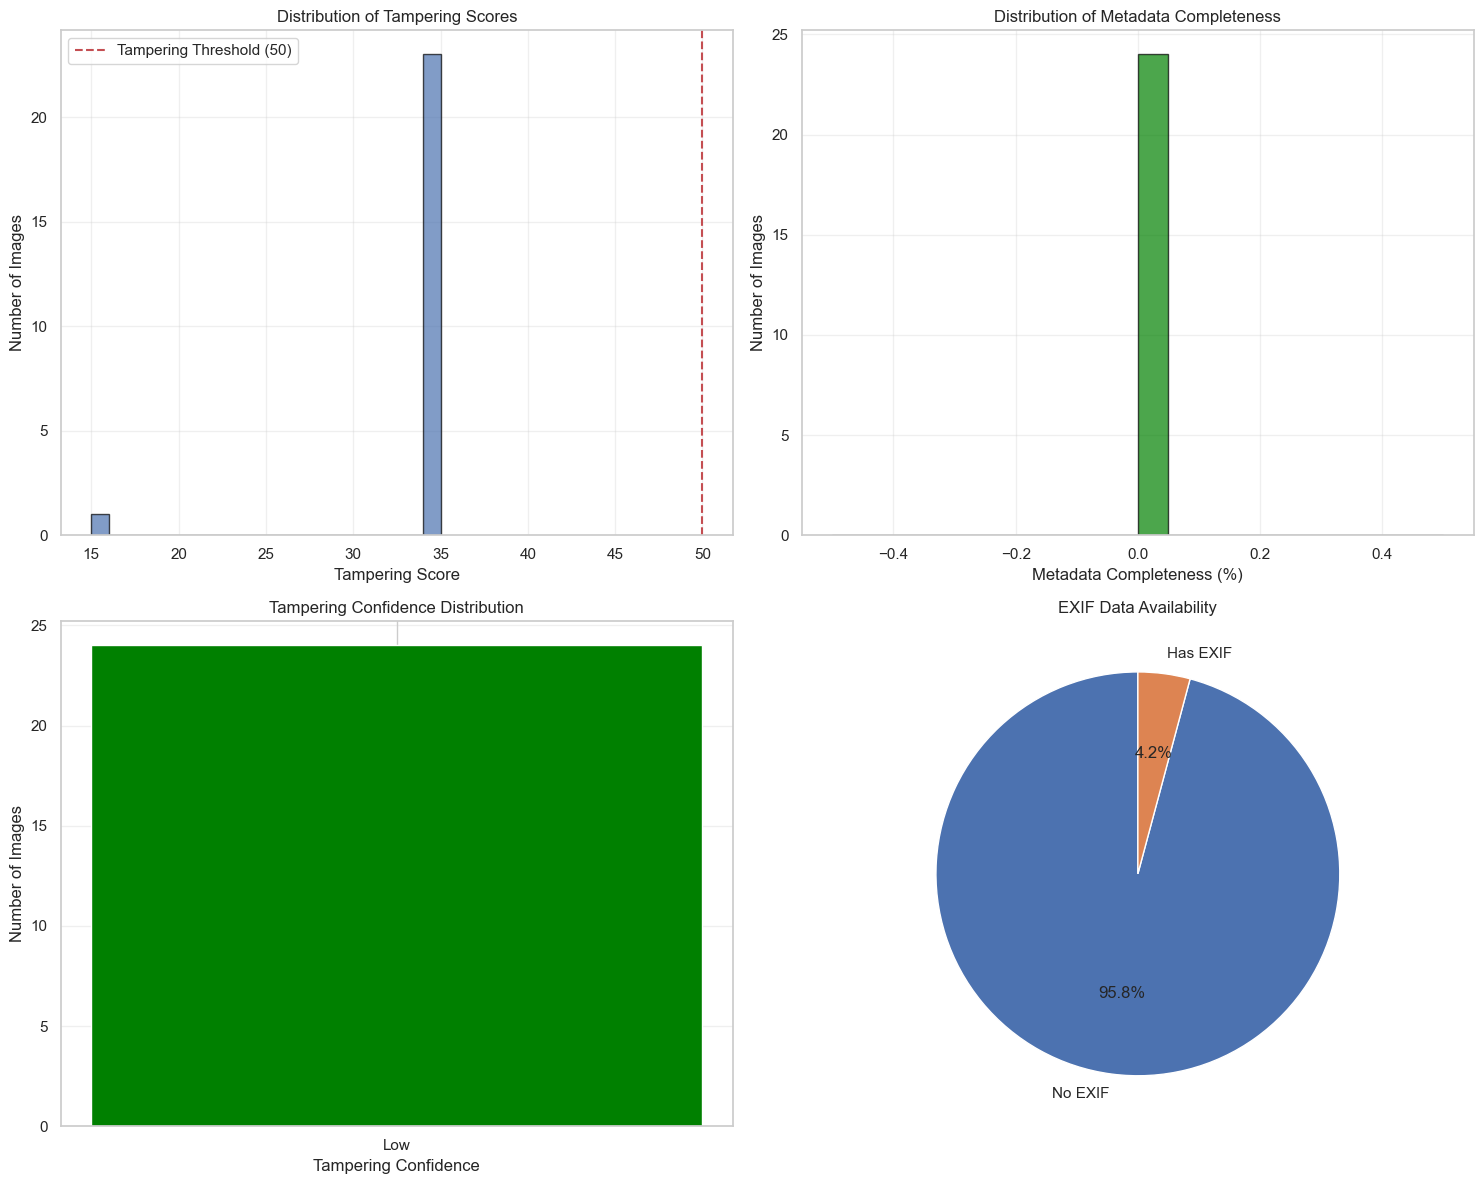

In [8]:
if 'analysis_results' in locals() and analysis_results and len(analysis_results) > 0:
    df_summary = create_summary_dataframe(analysis_results)
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Tampering Score Distribution
    axes[0, 0].hist(df_summary['tampering_score'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Tampering Score')
    axes[0, 0].set_ylabel('Number of Images')
    axes[0, 0].set_title('Distribution of Tampering Scores')
    axes[0, 0].axvline(x=50, color='r', linestyle='--', label='Tampering Threshold (50)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Metadata Completeness
    axes[0, 1].hist(df_summary['metadata_completeness'], bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_xlabel('Metadata Completeness (%)')
    axes[0, 1].set_ylabel('Number of Images')
    axes[0, 1].set_title('Distribution of Metadata Completeness')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Tampering Confidence Distribution
    confidence_counts = df_summary['tampering_confidence'].value_counts()
    axes[1, 0].bar(confidence_counts.index, confidence_counts.values, color=['green', 'orange', 'red'])
    axes[1, 0].set_xlabel('Tampering Confidence')
    axes[1, 0].set_ylabel('Number of Images')
    axes[1, 0].set_title('Tampering Confidence Distribution')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. EXIF Availability
    exif_counts = df_summary['has_exif'].value_counts()
    axes[1, 1].pie(exif_counts.values, labels=['No EXIF', 'Has EXIF'], autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title('EXIF Data Availability')
    
    plt.tight_layout()
    
    # Save figure
    fig_path = os.path.join(RESULTS_DIR, 'metadata_analysis_visualizations.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✓ Visualizations saved to: {fig_path}")
    
    plt.show()
else:
    print("No results to visualize. Please run the analysis first.")


## Detailed Report for Each Image


In [9]:
# Generate detailed reports for all analyzed images
if 'analysis_results' in locals() and analysis_results:
    print("Generating detailed reports for each image...")
    
    for result in analysis_results:
        print_metadata_report(result)
        print("\n")
    
    # Save detailed results to JSON
    json_path = os.path.join(RESULTS_DIR, 'detailed_metadata_analysis.json')
    
    # Convert datetime objects to strings for JSON serialization
    json_results = []
    for result in analysis_results:
        json_result = result.copy()
        # Convert timestamps
        json_result['timestamps'] = {k: v.isoformat() if v else None 
                                     for k, v in json_result['timestamps'].items()}
        json_result['file_timestamps'] = {k: v.isoformat() if v else None 
                                         for k, v in json_result['file_timestamps'].items()}
        if json_result['analysis_summary'].get('estimated_tampering_time'):
            json_result['analysis_summary']['estimated_tampering_time'] = \
                json_result['analysis_summary']['estimated_tampering_time'].isoformat()
        json_results.append(json_result)
    
    with open(json_path, 'w') as f:
        json.dump(json_results, f, indent=2)
    
    print(f"✓ Detailed results saved to: {json_path}")
else:
    print("No results to save. Please run the analysis first.")


Generating detailed reports for each image...
METADATA ANALYSIS REPORT: Ankita_with_heart_filter.jpg

Image Path: datasets/ai_detection/test/Ankita_with_heart_filter.jpg
Has EXIF Data: True
Metadata Completeness: 0.0%

--- TIMESTAMPS ---
  No EXIF timestamps found

--- FILE TIMESTAMPS ---
  file_created: 2025-11-25 18:35:01
  file_modified: 2025-11-25 18:35:01
  file_accessed: 2025-11-25 21:31:04

--- KEY EXIF INFORMATION ---

--- TAMPERING ANALYSIS ---
Tampering Score: 15/100
Likely Tampered: False
Confidence: Low
Metadata Quality: Minimal

Tampering Indicators:
  1. Missing DateTimeOriginal - original capture time unknown
  2. No GPS data found (may indicate AI-generated or processed image)



METADATA ANALYSIS REPORT: fake_9.jpg

Image Path: datasets/ai_detection/test/fake_9.jpg
Has EXIF Data: False
Metadata Completeness: 0.0%

--- TIMESTAMPS ---
  No EXIF timestamps found

--- FILE TIMESTAMPS ---
  file_created: 2025-11-25 00:41:19
  file_modified: 2025-11-25 00:41:19
  file_access

## Quick Analysis Function


In [10]:
def quick_analyze(image_path):
    """Quick analysis function for single image - returns key information."""
    result = analyze_image_metadata(image_path)
    
    print(f"\n{'='*60}")
    print(f"QUICK ANALYSIS: {result['image_name']}")
    print(f"{'='*60}")
    
    # Key timestamps
    if result['timestamps']:
        print("\n📅 EXIF Timestamps:")
        for label, dt in result['timestamps'].items():
            print(f"   {label}: {dt.strftime('%Y-%m-%d %H:%M:%S')}")
    
    file_mod = result['file_timestamps'].get('file_modified')
    if file_mod:
        print(f"\n📁 File Modified: {file_mod.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Tampering assessment
    print(f"\n🔍 Tampering Assessment:")
    print(f"   Score: {result['tampering_score']}/100")
    print(f"   Likely Tampered: {'YES' if result['analysis_summary']['likely_tampered'] else 'NO'}")
    print(f"   Confidence: {result['analysis_summary']['tampering_confidence']}")
    
    if result['analysis_summary'].get('estimated_tampering_time'):
        tamper_time = result['analysis_summary']['estimated_tampering_time']
        print(f"\n⏰ Estimated Tampering Time: {tamper_time.strftime('%Y-%m-%d %H:%M:%S')}")
    
    if result['tampering_indicators']:
        print(f"\n⚠️  Key Indicators:")
        for indicator in result['tampering_indicators'][:3]:  # Show top 3
            print(f"   • {indicator}")
    
    print(f"\n{'='*60}\n")
    
    return result


# Example usage:
# result = quick_analyze('datasets/ai_detection/test/real_1.jpg')


## Export Full EXIF Data


In [11]:
def export_full_exif(image_path, output_path=None):
    """Export all EXIF data to a readable format."""
    result = analyze_image_metadata(image_path)
    
    if output_path is None:
        output_path = os.path.join(RESULTS_DIR, f"{result['image_name']}_full_exif.json")
    
    # Prepare export data
    export_data = {
        'image_name': result['image_name'],
        'image_path': result['image_path'],
        'analysis_date': datetime.now().isoformat(),
        'exif_data': result['exif_data'],
        'timestamps': {k: v.isoformat() if v else None for k, v in result['timestamps'].items()},
        'file_timestamps': {k: v.isoformat() if v else None for k, v in result['file_timestamps'].items()},
        'tampering_analysis': {
            'score': result['tampering_score'],
            'indicators': result['tampering_indicators'],
            'summary': result['analysis_summary']
        }
    }
    
    with open(output_path, 'w') as f:
        json.dump(export_data, f, indent=2)
    
    print(f"✓ Full EXIF data exported to: {output_path}")
    return export_data


# Example: Export EXIF for a specific image
# export_full_exif('datasets/ai_detection/test/real_1.jpg')
